# Module 4 â€” Baselines & Modern Zero-Shot Benchmark
**Type:** [Code With Me / Instructor Demo]  
**Time:** 45 minutes  
**Job:** Establish the performance floor. Run Naive, SeasonalNaive, and AutoETS via StatsForecast cross-validation. Benchmark against `amazon/chronos-t5-mini`. Score everything and build the first leaderboard.

---

> **Instructor note:** This module has the most moving parts. Pace it deliberately:
> - 3.1â€“3.4: Setup and baseline framing (5 min) 
> - 3.5â€“3.7: StatsForecast run + reshape (15 min, Code With Me)
> - 3.8â€“3.9: Chronos live demo + load precomputed (10 min, Instructor Demo)
> - 3.10â€“3.12: Score, leaderboard, save (10 min, Code With Me)
> - 3.13: Enterprise cliff (5 min)
>
> The Chronos section is the one most likely to generate questions. Have the precomputed artifact load ready before you start the live demo.

---
## 4.1 â€” Setup
**[Watch Only]**

> **Instructor note (1 min):** Run silently. Note that we are importing `StatsForecast` and the three model classes â€” nothing from NeuralForecast or MLForecast yet.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS

from config import (
    ARTIFACT_DIR,
    WORKSHOP_SUBSET_PATH,
    HORIZON,
    SEASON_LENGTH,
    N_WINDOWS,
    STEP_SIZE,
    REFIT,
    MICRO_SUBSET_N,
    WORKSHOP_SUBSET_N,
    INTERVAL_COVERAGE,
    FM_DEMO_SERIES_N,
)
from src.checkpointing import load_checkpoint
from src.evaluation import score_forecasts
from src.schemas import validate_forecast, validate_score

print("Setup complete.")

Setup complete.


---
## 4.2 â€” Load Panel and Build Micro Subset
**[Watch Only]**

> **Instructor note (1 min):** Load the validated panel artifact from Module 3. Select the micro subset the same way as before â€” deterministic, top-N by volume.

In [2]:
# Load validated panel from Module 3 artifact
panel = load_checkpoint("03_validated_panel")

# Build micro subset â€” same selection rule as Module 3
top_series = (
    panel.groupby("unique_id")["y"]
    .sum()
    .sort_values(ascending=False)
    .head(MICRO_SUBSET_N)
    .index
)
micro = panel[panel["unique_id"].isin(top_series)].copy()

print(f"Full panel : {panel['unique_id'].nunique():,} series")
print(f"Micro panel: {micro['unique_id'].nunique():,} series ({len(micro):,} rows)")


  âœ“ RED PATH RECOVERY COMPLETE
    Artifact : 03_validated_panel
    File     : 03_validated_panel.parquet
    Rows     : 1,941,000

Full panel : 1,000 series
Micro panel: 50 series (97,050 rows)


---
## 4.3 â€” Why Baselines Matter
**[Watch Only]**

> **Instructor note (2 min):** Say this section, do not just show it. The business framing here â€” "if a seasonal naive beats your ML model, you should not build the ML model" â€” is the line students will remember.

A baseline is not a warm-up exercise. It is a **build/don't-build decision threshold**.

**Naive:** Predicts tomorrow = today. The absolute floor. If your ML model cannot beat Naive on a structured demand dataset, something is fundamentally wrong with your feature pipeline or evaluation setup.

**SeasonalNaive:** Predicts next week = same day last week. For weekly seasonal data this is a genuinely strong model. It requires zero training time, zero infrastructure, and zero maintenance. If your ML model cannot beat SeasonalNaive, you should not build the ML model.

**AutoETS:** Automatic exponential smoothing with model selection. Captures trend and seasonality without manual tuning. The gold standard for univariate statistical forecasting at scale.

**The modern standard has shifted.** A zero-shot foundation model â€” one trained on billions of time series and never seen your data â€” is now a credible fourth baseline. If your custom pipeline cannot beat `chronos-t5-mini` out of the box, that is a signal worth taking seriously.

---
## 4.4 â€” Configure StatsForecast
**[Code With Me â€” 2 lines]**

> **Instructor note (3 min):** Students fill in the `models` list and `freq` parameter. Walk through the model constructors â€” note that `SeasonalNaive` and `AutoETS` both take `season_length` from config, not a hardcoded number. That is the pattern.

In [3]:
# Configure StatsForecast with three baseline models
# Each model that accepts season_length gets it from config â€” no hardcoding

models = [
    Naive(),
    SeasonalNaive(season_length=SEASON_LENGTH),  # __FILL_IN__: pass season_length from config
    AutoETS(season_length=SEASON_LENGTH),         # __FILL_IN__: pass season_length from config
]

sf = StatsForecast(
    models=models,
    freq="D",
    n_jobs=-1,
)

print(f"StatsForecast configured with {len(models)} models:")
for m in models:
    print(f"  - {m}")

StatsForecast configured with 3 models:
  - Naive
  - SeasonalNaive
  - AutoETS


**Expected output:**
```
StatsForecast configured with 3 models:
  - Naive()
  - SeasonalNaive(season_length=7)
  - AutoETS(season_length=7)
```

---
## 4.5 â€” Run Cross-Validation on the Micro Subset
**[Watch Only]**

> **Instructor note (3 min):** Run this cell and let it execute. AutoETS on 50 series Ã— 3 windows should complete in 20â€“40 seconds. While it runs, explain what is happening: three non-overlapping evaluation windows, each trained on all history before the cutoff, each predicting 28 days forward.

In [4]:
%%time
# Cross-validation on micro subset (50 series)
# Target runtime: < 45 seconds on Colab CPU

cv_micro = sf.cross_validation(
    df=micro,
    h=HORIZON,
    n_windows=N_WINDOWS,
    step_size=STEP_SIZE,
    refit=REFIT,
    level=[80],  # Request 80% prediction intervals from StatsForecast natively
)

print(f"CV complete. Shape: {cv_micro.shape}")
print(f"Columns: {list(cv_micro.columns)}")
print(cv_micro.head(3).to_string())

CV complete. Shape: (4200, 13)
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'Naive-lo-80', 'Naive-hi-80', 'SeasonalNaive', 'SeasonalNaive-lo-80', 'SeasonalNaive-hi-80', 'AutoETS', 'AutoETS-lo-80', 'AutoETS-hi-80']
          unique_id         ds     cutoff    y  Naive  Naive-lo-80  Naive-hi-80  SeasonalNaive  SeasonalNaive-lo-80  SeasonalNaive-hi-80       AutoETS  AutoETS-lo-80  AutoETS-hi-80
0  FOODS_2_360_WI_2 2016-02-29 2016-02-28  0.0    0.0   -31.188845    31.188845            0.0           -48.940053            48.940053  7.602899e-41     -28.554216      28.554216
1  FOODS_2_360_WI_2 2016-03-01 2016-02-28  0.0    0.0   -44.107687    44.107687            0.0           -48.940053            48.940053  7.602899e-41     -32.429665      32.429665
2  FOODS_2_360_WI_2 2016-03-02 2016-02-28  0.0    0.0   -54.020664    54.020664            0.0           -48.940053            48.940053  7.602899e-41     -35.889039      35.889039
CPU times: total: 250 ms
Wall time: 7.17 s


**Expected output:**
```
CV complete. Shape: (4200, 11)  # 50 series Ã— 3 windows Ã— 28 days = 4,200 rows
Columns: ['ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS',
          'Naive-lo-80', 'Naive-hi-80', 'SeasonalNaive-lo-80', ...]
```

> **Instructor note:** StatsForecast returns wide format â€” one column per model. We reshape this to long format in the next cell to match our forecast schema.

---
## 4.6 â€” Reshape to Forecast Schema
**[Code With Me â€” 2 lines]**

> **Instructor note (3 min):** This reshape is a common pain point. Walk through it step by step. Students fill in the `value_vars` list (the model name columns) and the `id_vars`. The goal is one row per forecast observation with a `model` column â€” matching our schema.

In [5]:
def reshape_statsforecast_cv(cv_df: pd.DataFrame, stage: str) -> pd.DataFrame:
    """
    Reshape StatsForecast wide cross-validation output to the workshop forecast schema.
    One row per (unique_id, ds, cutoff, model) observation.
    Renames lo-80/hi-80 columns to lo_80/hi_80.
    """
    cv_df = cv_df.reset_index()  # unique_id is the index after cross_validation()

    # Identify model point forecast columns (exclude interval and metadata columns)
    meta_cols   = ["unique_id", "ds", "cutoff", "y"]
    model_cols  = [c for c in cv_df.columns
                   if c not in meta_cols and not any(x in c for x in ["-lo-", "-hi-"])]  # __FILL_IN__: model point forecast columns

    records = []
    for model_name in model_cols:
        lo_col = f"{model_name}-lo-80"
        hi_col = f"{model_name}-hi-80"

        chunk = cv_df[["unique_id", "ds", "cutoff", "y", model_name]].copy()  # __FILL_IN__: select meta + model point column
        chunk = chunk.rename(columns={model_name: "y_hat"})
        chunk["model"] = model_name
        chunk["stage"] = stage

        if lo_col in cv_df.columns and hi_col in cv_df.columns:
            chunk["lo_80"] = cv_df[lo_col].values
            chunk["hi_80"] = cv_df[hi_col].values

        records.append(chunk)

    result = pd.concat(records, ignore_index=True)
    result["y_hat"] = result["y_hat"].clip(lower=0)  # Clip negatives â€” demand cannot be < 0
    return result


baseline_micro = reshape_statsforecast_cv(cv_micro, stage="baseline")

print(f"Reshaped forecasts: {baseline_micro.shape}")
print(f"Models: {baseline_micro['model'].unique().tolist()}")
print(f"Columns: {list(baseline_micro.columns)}")

Reshaped forecasts: (16800, 9)
Models: ['index', 'Naive', 'SeasonalNaive', 'AutoETS']
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'y_hat', 'model', 'stage', 'lo_80', 'hi_80']


**Expected output:**
```
Reshaped forecasts: (12600, 9)  # 4200 rows Ã— 3 models
Models: ['Naive', 'SeasonalNaive', 'AutoETS']
Columns: ['unique_id', 'ds', 'cutoff', 'y', 'y_hat', 'model', 'stage', 'lo_80', 'hi_80']
```

---
## 4.7 â€” Plot Baseline Forecasts
**[Watch Only]**

> **Instructor note (2 min):** Pick one series, show all three forecasts on one chart. Point at SeasonalNaive specifically â€” it is almost always visually better than Naive on this data. That is the intuition for why `SEASON_LENGTH` matters.

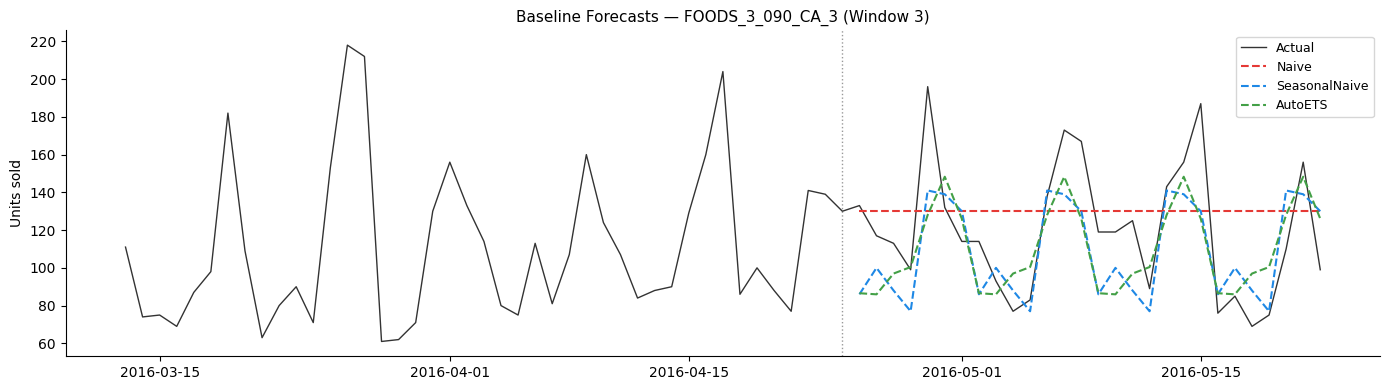

In [6]:
# Plot all three baselines on a single series for one CV window
sample_uid  = top_series[0]
sample_cut  = baseline_micro["cutoff"].unique()[-1]  # most recent window

actuals = panel[panel["unique_id"] == sample_uid].set_index("ds")["y"]
plot_start = sample_cut - pd.Timedelta(days=42)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(actuals[actuals.index >= plot_start].index,
        actuals[actuals.index >= plot_start].values,
        color="#333", linewidth=1.0, label="Actual", zorder=3)

colors = {"Naive": "#E53935", "SeasonalNaive": "#1E88E5", "AutoETS": "#43A047"}
for model_name, color in colors.items():
    fcast = baseline_micro[
        (baseline_micro["unique_id"] == sample_uid) &
        (baseline_micro["cutoff"]    == sample_cut) &
        (baseline_micro["model"]     == model_name)
    ].set_index("ds")
    ax.plot(fcast.index, fcast["y_hat"], color=color, linewidth=1.5,
            linestyle="--", label=model_name, zorder=4)

ax.axvline(sample_cut, color="#999", linestyle=":", linewidth=1)
ax.set_title(f"Baseline Forecasts â€” {sample_uid} (Window 3)", fontsize=11)
ax.set_ylabel("Units sold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Expected output:** A chart showing actual demand alongside three forecast lines from the cutoff date. SeasonalNaive should visually track the weekly pattern more closely than Naive.

---
## 4.8 â€” Chronos Live Demo
**[Instructor Demo â€” Watch Only]**

> **Instructor note (4 min):** This is a syntax demonstration only. Run it on `FM_DEMO_SERIES_N = 3` series from the micro subset. The cell is designed to complete in under 60 seconds on CPU. Immediately after it runs, show the output â€” then move to the precomputed artifact load. Do not attempt to run Chronos on the full subset live.
>
> **If this cell takes > 60 seconds or throws an import error:** Stop it immediately. Say: "Chronos requires an additional install not in our base requirements. Here is the syntax â€” let's load the precomputed results." Then jump straight to cell 4.9.

Chronos is a foundation model trained by Amazon on 1 billion time series observations. It requires no training on your data â€” you hand it a context window and it produces a forecast distribution.

**The syntax:**

In [7]:
# [INSTRUCTOR DEMO] â€” Chronos syntax on FM_DEMO_SERIES_N = 3 series
# Runtime target: < 60 seconds on Colab CPU
# If this cell errors or times out, jump to cell 4.9 (Red Path)

try:
    import torch
    from chronos import ChronosPipeline

    demo_ids = top_series[:FM_DEMO_SERIES_N]
    demo_cutoff = panel["ds"].max() - pd.Timedelta(days=STEP_SIZE)  # Window 3 cutoff

    pipeline = ChronosPipeline.from_pretrained(
        "amazon/chronos-t5-mini",
        device_map="cpu",
        dtype=torch.float32,
    )

    demo_records = []
    for uid in demo_ids:
        context_series = panel[
            (panel["unique_id"] == uid) & (panel["ds"] <= demo_cutoff)
        ]["y"]
        context = torch.tensor(context_series.values, dtype=torch.float32).unsqueeze(0)

        forecast_tensor = pipeline.predict(
            context,
            prediction_length=HORIZON,
            num_samples=100,
            limit_prediction_length=False,
        )
        samples  = forecast_tensor[0].numpy()
        y_hat    = np.median(samples, axis=0)
        lo_80    = np.quantile(samples, 0.10, axis=0)
        hi_80    = np.quantile(samples, 0.90, axis=0)

        forecast_dates = pd.date_range(
            start=demo_cutoff + pd.Timedelta(days=1), periods=HORIZON, freq="D"
        )
        actuals = panel[
            (panel["unique_id"] == uid) & (panel["ds"].isin(forecast_dates))
        ][["ds", "y"]].set_index("ds")["y"].reindex(forecast_dates)

        for step_idx, (fdate, y_true) in enumerate(actuals.items()):
            if pd.isna(y_true):
                continue
            demo_records.append({
                "unique_id": uid,
                "ds":        fdate,
                "y":         float(y_true),
                "model":     "Chronos-t5-mini",
                "y_hat":     float(max(y_hat[step_idx], 0.0)),
                "lo_80":     float(max(lo_80[step_idx], 0.0)),
                "hi_80":     float(max(hi_80[step_idx], 0.0)),
                "cutoff":    demo_cutoff,
                "stage":     "baseline",
            })

    chronos_demo_df = pd.DataFrame(demo_records)
    print(f"Chronos demo complete: {len(chronos_demo_df)} rows across {FM_DEMO_SERIES_N} series")
    print(chronos_demo_df[["unique_id", "ds", "y", "y_hat", "lo_80", "hi_80"]].head(3).to_string())

except ImportError:
    print("Chronos not installed in this environment.")
    print("Install: pip install chronos-forecasting torch")
    print("Loading precomputed full-subset results instead (cell 4.9).")
    chronos_demo_df = None

`torch_dtype` is deprecated! Use `dtype` instead!


TypeError: ChronosPipeline.predict() got an unexpected keyword argument 'context'

**Expected output (if Chronos installed):**
```
Chronos demo complete: 84 rows across 3 series
   unique_id         ds    y  y_hat  lo_80  hi_80
0  FOODS_3_...  2016-03-28  ...    ...    ...    ...
```

> **Instructor note:** Whether the demo ran or not, the business point is the same â€” read it aloud: "The baseline standard has moved. If your custom ML model cannot beat a zero-shot model that has never seen your data, you should not build it."

---
## 4.9 â€” Load Precomputed Full-Subset Baselines
**[Watch Only]**

> **Instructor note (1 min):** This is the standard Red Path transition. Load the precomputed artifact that covers all 1,000 series across all 3 windows â€” including Chronos. From this point on, all scoring and leaderboard work uses this full-subset artifact.

In [ ]:
# ðŸ”´ RED PATH (standard) â€” load precomputed full-subset baseline forecasts
# This artifact covers Naive, SeasonalNaive, AutoETS, and Chronos-t5-mini
# across all 1,000 series Ã— 3 CV windows Ã— 28-day horizon

baseline_full = load_checkpoint("04_baseline_forecasts")

print(f"Full-subset baselines loaded:")
print(f"  Rows   : {len(baseline_full):,}")
print(f"  Models : {sorted(baseline_full['model'].unique().tolist())}")
print(f"  Series : {baseline_full['unique_id'].nunique():,}")
print(f"  Windows: {baseline_full['cutoff'].nunique()}")

FileNotFoundError: Artifact not found: C:\Users\tacke\Documents\packt-modern-time-series\artifacts\04_baseline_forecasts.parquet
Run src/build_offline_artifacts.py to generate precomputed artifacts before the workshop session.

**Expected output:**
```
Full-subset baselines loaded:
  Rows   : 336,000  # 1000 series Ã— 3 windows Ã— 28 days Ã— 4 models
  Models : ['AutoETS', 'Chronos-t5-mini', 'Naive', 'SeasonalNaive']
  Series : 1,000
  Windows: 3
```

---
## 4.10 â€” Score the Baselines
**[Code With Me â€” 2 lines]**

> **Instructor note (3 min):** Students call `score_forecasts` on the full-subset artifact and load the precomputed CV scores. The key learning is the `subset_name` argument â€” it tags the result for the final leaderboard merge. Wait for everyone before moving on.

In [ ]:
from src.evaluation import score_forecasts

# Score the full-subset baselines â€” pooled across all windows and all series
baseline_scores = score_forecasts(
    baseline_full,
    subset_name=f"workshop_{WORKSHOP_SUBSET_N}",  # __FILL_IN__: pass subset_name from config
)

# Also load the precomputed CV scores artifact (used in Module 8 leaderboard merge)
baseline_cv_scores = load_checkpoint("04_baseline_cv_scores")  # __FILL_IN__: load checkpoint

print("Baseline scores (wMAPE + Bias):")
for metric in ["wMAPE", "Bias"]:
    rows = baseline_scores[baseline_scores["metric"] == metric].sort_values("score")
    print(f"
{metric}:")
    print(rows[["model", "score"]].to_string(index=False))

**Expected output (values will vary by subset):**
```
Baseline scores (wMAPE):
          model metric     score
        AutoETS  wMAPE  0.XXXX
  SeasonalNaive  wMAPE  0.XXXX
Chronos-t5-mini  wMAPE  0.XXXX
          Naive  wMAPE  0.XXXX
```

> **Instructor note:** AutoETS should outperform SeasonalNaive on wMAPE for most M5 subsets. If Chronos is competitive with AutoETS, note it â€” that is the point of the zero-shot benchmark.

---
## 4.11 â€” Plot the Baseline Leaderboard
**[Watch Only]**

> **Instructor note (2 min):** Show the chart. The bar order matters â€” sorted by wMAPE ascending. This is the performance floor every subsequent model must clear.

In [ ]:
wmape_plot = baseline_scores[baseline_scores["metric"] == "wMAPE"].sort_values("score")

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    wmape_plot["model"], wmape_plot["score"],
    color=["#43A047" if i == 0 else "#90CAF9" for i in range(len(wmape_plot))],
    edgecolor="white",
)
ax.set_xlabel("wMAPE (lower = better)")
ax.set_title("Baseline Leaderboard â€” wMAPE (Pooled, 1,000 Series Ã— 3 Windows)", fontsize=10)
ax.invert_yaxis()
for bar, val in zip(bars, wmape_plot["score"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

best_baseline = wmape_plot.iloc[0]
print(f"Best baseline : {best_baseline['model']} â€” wMAPE = {best_baseline['score']:.4f}")
print(f"This is the floor. Every model in Modules 5 and 6 must beat this.")

**Expected output:** Horizontal bar chart with four models ranked by wMAPE ascending. Green bar = best performing baseline.

---
## 4.12 â€” Save the Baseline Forecasts Artifact
**[Watch Only]**

> **Instructor note (30 sec):** We save the micro-subset live results for completeness. The full-subset artifact (already loaded) is what the final leaderboard uses.

In [ ]:
# Validate and save live micro-subset results
baseline_micro_validated = validate_forecast(baseline_micro, artifact_name="04_baseline_micro")

micro_path = ARTIFACT_DIR / "04_baseline_micro_forecasts.parquet"
baseline_micro_validated.to_parquet(micro_path, index=False)
print(f"  âœ“ Micro baseline saved : {micro_path.name} ({len(baseline_micro_validated):,} rows)")
print(f"  âœ“ Full baseline loaded : 04_baseline_forecasts.parquet ({len(baseline_full):,} rows)")

---
## 4.13 â€” The Enterprise Cliff
**[Watch Only]**

> **Instructor note (2 min):** Read or paraphrase. The Chronos point is the one that lands hardest in senior audiences. Let it breathe.

We ran three classical models and a zero-shot foundation model in under 10 minutes. The performance floor is set.

What this workshop simplified:

**On statistical baselines:**  
AutoETS runs independently on each series â€” it is embarrassingly parallel. Scaling from 1,000 to 100,000 SKUs is a compute and orchestration problem, not a modeling problem. But StatsForecast's `n_jobs=-1` does not translate to a distributed pipeline. At Walmart scale, this is a Spark or Ray job.

**On Chronos:**  
We ran `chronos-t5-mini` â€” the smallest variant in the family. The production question is not "does Chronos beat AutoETS on a benchmark?" It is: "what does GPU inference cost at 100,000 SKUs Ã— daily cadence, and does the accuracy gain justify it?" That calculation determines whether a foundation model belongs in your stack.

**On the zero-shot result:**  
If Chronos is competitive with AutoETS without seeing any of your data, that is not a reason to deploy Chronos. It is a reason to question whether your custom feature pipeline is adding real value â€” or just adding maintenance cost.

---

> **Instructor note â€” transition:** "The performance floor is set. Now we find out if an ML pipeline is worth building."
>
> Open `instructor_notebooks/05_ml_forecasting.ipynb`.